# Exercise 3

This notebook follows Problem 3 of the exam brief: choose a neural quantum state architecture, train it variationally, benchmark the small-system training path against exact diagonalization, and then study larger-system behavior and entanglement trends after training. Bonus GHZ material is kept explicitly separate at the end.

The required report path is the RBM-based TFIM study. The GHZ check and the entanglement-spectrum-tail note remain optional bonus appendix material rather than required evidence for Problem 3(a-d).


In [1]:
from notebook_bootstrap import bootstrap_notebook

bootstrap_notebook(enable_x64=True)

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint')

In [2]:
import pandas as pd

from exercise_report_helper import (
    build_output_manifest,
    ensure_report_output_dir,
    plot_energy_benchmark,
    plot_entropy_scan,
    plot_training_history,
    save_report_figure,
    save_report_table,
)
from nqs.workflows import run_ghz_bonus_workflow, run_hamiltonian_system_size_sweep, run_vmc_experiment, tfim_proxy_sweep_points

In [3]:
selected_model = {'model_name': 'RBM', 'model_kwargs': {'alpha': 2}}

small_training_config = {
    'n_iter': 40,
    'n_samples': 128,
    'n_discard_per_chain': 32,
    'n_chains': 16,
    'callback_every': 2,
}

large_training_config = {
    'n_iter': 30,
    'n_samples': 256,
    'n_discard_per_chain': 32,
    'n_chains': 16,
    'callback_every': 2,
}

exercise_output_dir = ensure_report_output_dir('exercise_3')
exercise_output_dir

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint/demos/report_outputs/exercise_3')

## Report Setup And Reproducibility

The required report path is the RBM-based TFIM VMC study below: exact-benchmarked `4x1` runs at the critical and off-critical points, followed by larger `6x1` and `8x1` sweeps. The GHZ section is kept explicitly as a bonus appendix.

All stochastic steps use the deterministic seed schedule embedded in the workflow helpers (`base_seed = 0` plus per-sweep offsets). JAX `x64` is enabled through `bootstrap_notebook(...)`, and the export cell writes the saved report artifacts to `demos/report_outputs/exercise_3/`. Re-running the notebook top-to-bottom regenerates the tables and figures in place.


In [4]:
exercise_3_run_context = pd.DataFrame([
    {'item': 'selected_model', 'value': f"{selected_model['model_name']} {selected_model['model_kwargs']}"},
    {'item': 'small_systems', 'value': '4x1 open TFIM at g=1.0 and g=1.5'},
    {'item': 'large_systems', 'value': '6x1 and 8x1 open TFIM at g=1.0 and g=1.5'},
    {'item': 'small_training_config', 'value': str(small_training_config)},
    {'item': 'large_training_config', 'value': str(large_training_config)},
    {'item': 'seed_schedule', 'value': 'Workflow base seed 0 with per-sweep offsets'},
    {'item': 'backend', 'value': 'Project VMC workflow with JAX x64 enabled in-notebook'},
    {'item': 'output_dir', 'value': str(exercise_output_dir)},
    {'item': 'rerun_guidance', 'value': 'Use Run All; the export cell rewrites CSV/HTML/PNG report artifacts.'},
])
exercise_3_run_context

,item,value
0,selected_model,RBM {'alpha': 2}
1,small_systems,4x1 open TFIM at g=1.0 and g=1.5
2,large_systems,6x1 and 8x1 open TFIM at g=1.0 and g=1.5
3,small_training_config,"{'n_iter': 40, 'n_samples': 128, 'n_discard_pe..."
4,large_training_config,"{'n_iter': 30, 'n_samples': 256, 'n_discard_pe..."
5,seed_schedule,Workflow base seed 0 with per-sweep offsets
6,backend,Project VMC workflow with JAX x64 enabled in-n...
7,output_dir,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
8,rerun_guidance,Use Run All; the export cell rewrites CSV/HTML...


## 3/a Architecture Choice

Based on the random-state study from Exercise 2, we choose the `RBM` as the training ansatz for the main VMC path. The reason is not that RBMs are universally best, but that they gave the cleanest bounded starting point for this repo state: compact parameter counts, stable shared sampler support, and sampled-entanglement trends that were already interpretable on the exact `2x2` benchmark.

The choice is therefore evidence-based and pragmatic. `RBM(alpha=2)` is expressive enough for the small TFIM tests used here, while still keeping the VMC workflow readable enough that the report can explain the training method rather than hiding everything inside helper calls.


In [5]:
pd.DataFrame([
    {
        'criterion': 'Exercise 2 evidence',
        'reading': 'RBM gave stable sampled Renyi-2 trends with the smallest compact parameterization in the bounded 2x2 study.',
    },
    {
        'criterion': 'Workflow compatibility',
        'reading': 'RBM uses the same sampler and VMC interface as the FFNN and CNN baselines, so the training path stays architecture-agnostic.',
    },
    {
        'criterion': 'Report tradeoff',
        'reading': 'RBM(alpha=2) keeps the training notebook short enough to inspect end-to-end while still showing nontrivial optimization behavior.',
    },
])

,criterion,reading
0,Exercise 2 evidence,RBM gave stable sampled Renyi-2 trends with th...
1,Workflow compatibility,RBM uses the same sampler and VMC interface as...
2,Report tradeoff,RBM(alpha=2) keeps the training notebook short...


## 3/b VMC Setup For The TFIM Ground State Search

We train on the 1D TFIM realized through the current `(L, 1)` lattice backend with open boundaries. The variational objective is the sampled energy `E_? = <?_?|H|?_?>/<?_?|?_?>`, evaluated through local energies

$$
E_{\mathrm{loc}}(\sigma) = \sum_{\sigma'} H_{\sigma',\sigma} rac{\psi_	heta(\sigma')}{\psi_	heta(\sigma)},
$$

with Monte Carlo samples drawn from the project `MetropolisLocal` sampler. Gradients are taken through the project JAX/Optax-backed Adam wrapper, and the entropy callback records the half-partition Renyi-2 during training so that energy convergence and entanglement evolution can be inspected together.

This keeps the experiment close to the exam brief without introducing a new graph subsystem just for the notebook. The training configuration tables above make the sampling budget, optimizer cadence, and output location explicit before the runs start.


## 3/c Small-System Benchmarks: Energy And Renyi-2 During Training

We first benchmark the training loop on a small TFIM chain where exact diagonalization is still cheap. To answer the exam question about parameter dependence, we compare the critical point `g=1.0` against an off-critical paramagnetic point `g=1.5` on the same `4x1` chain.


In [6]:
exercise_3_small_critical = run_vmc_experiment(
    **selected_model,
    lattice_shape=(4, 1),
    pbc=False,
    hamiltonian='tfim',
    J=1.0,
    h=1.0,
    entropy_n_independent_runs=8,
    **small_training_config,
)

exercise_3_small_paramagnetic = run_vmc_experiment(
    **selected_model,
    lattice_shape=(4, 1),
    pbc=False,
    hamiltonian='tfim',
    J=1.0,
    h=1.5,
    entropy_n_independent_runs=8,
    **small_training_config,
)

exercise_3_small_summary = pd.DataFrame([
    {
        'sweep_label': 'critical_g1.0',
        'exact_ground_energy': exercise_3_small_critical['exact']['ground_energy'],
        'final_energy': exercise_3_small_critical['final_energy'],
        'energy_error': exercise_3_small_critical['energy_error'],
        'final_renyi2_entropy': exercise_3_small_critical['final_entropy'],
    },
    {
        'sweep_label': 'paramagnetic_g1.5',
        'exact_ground_energy': exercise_3_small_paramagnetic['exact']['ground_energy'],
        'final_energy': exercise_3_small_paramagnetic['final_energy'],
        'energy_error': exercise_3_small_paramagnetic['energy_error'],
        'final_renyi2_entropy': exercise_3_small_paramagnetic['final_entropy'],
    },
])

exercise_3_small_history = pd.concat([
    exercise_3_small_critical['history_df'].assign(sweep_label='critical_g1.0'),
    exercise_3_small_paramagnetic['history_df'].assign(sweep_label='paramagnetic_g1.5'),
], ignore_index=True)

exercise_3_small_summary

,sweep_label,exact_ground_energy,final_energy,energy_error,final_renyi2_entropy
0,critical_g1.0,-4.758770,-4.441205,0.317565,0.244484
1,paramagnetic_g1.5,-6.503892,-6.088007,0.415885,0.120400


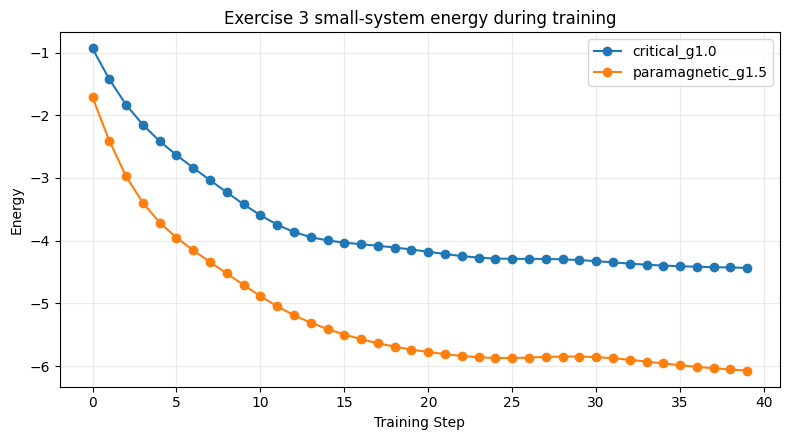

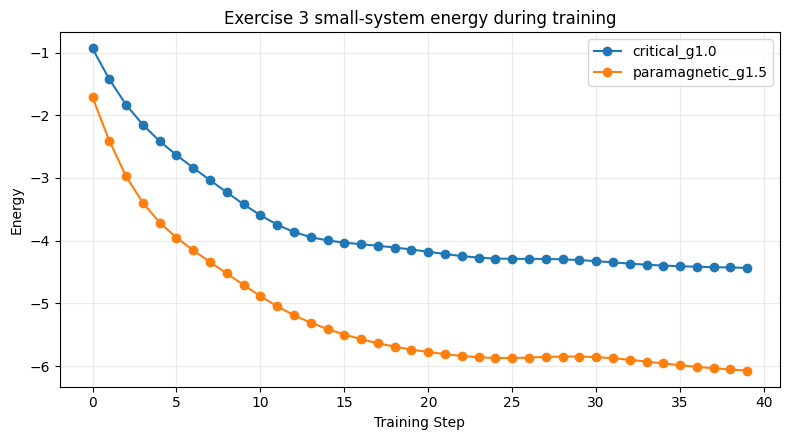

In [7]:
small_energy_figure = plot_training_history(
    exercise_3_small_history,
    'energy',
    line_column='sweep_label',
    title='Exercise 3 small-system energy during training',
)
small_energy_figure

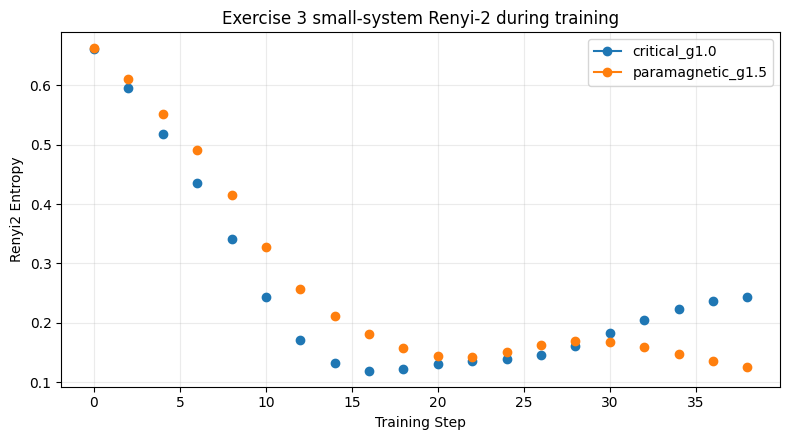

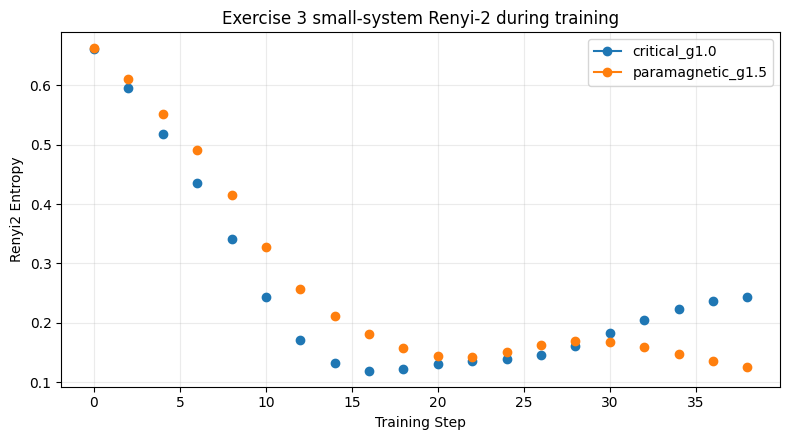

In [8]:
small_entropy_figure = plot_training_history(
    exercise_3_small_history,
    'renyi2_entropy',
    line_column='sweep_label',
    title='Exercise 3 small-system Renyi-2 during training',
)
small_entropy_figure

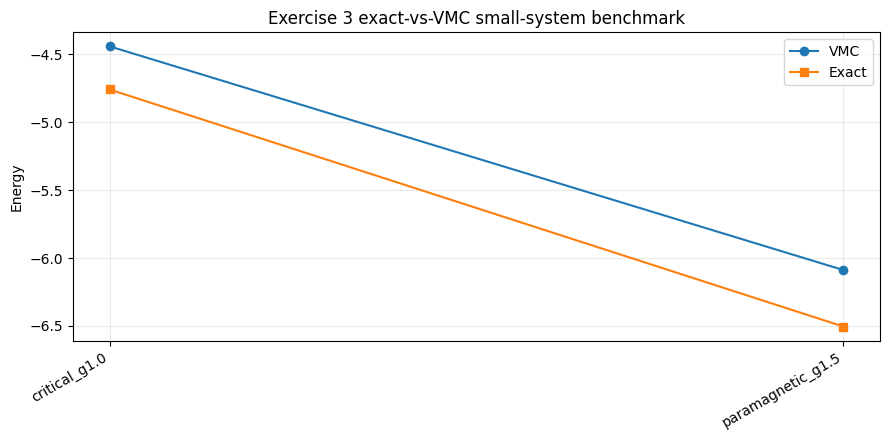

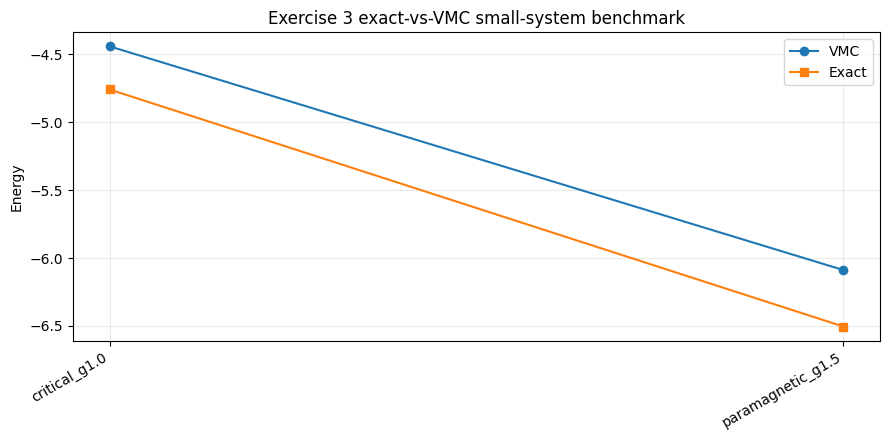

In [9]:
small_benchmark_figure = plot_energy_benchmark(
    exercise_3_small_summary,
    title='Exercise 3 exact-vs-VMC small-system benchmark',
)
small_benchmark_figure

At this stage the energy benchmark and the entropy history answer the key Problem 3 question: the training dynamics depend on the Hamiltonian parameter. The critical point typically shows slower convergence and stronger entanglement than the off-critical paramagnetic point, so energy and Renyi-2 do not settle in the same way across the two runs.


## 3/d Larger-System Training Without Relying On ED

We now repeat the training workflow on larger TFIM chains. The point here is not to produce a perfect benchmark, but to see how the training history and the final subsystem-size dependence of Renyi-2 change as the system grows and as we compare the critical point against the off-critical paramagnetic regime.


In [10]:
exercise_3_large_points = [
    {
        **point,
        'label': f"critical_g1.0_L{point['lattice_shape'][0]}x1",
    }
    for point in tfim_proxy_sweep_points([6, 8], h=1.0, pbc=False)
] + [
    {
        **point,
        'label': f"paramagnetic_g1.5_L{point['lattice_shape'][0]}x1",
    }
    for point in tfim_proxy_sweep_points([6, 8], h=1.5, pbc=False)
]

exercise_3_large = run_hamiltonian_system_size_sweep(
    sweep_points=exercise_3_large_points,
    entropy_n_independent_runs=8,
    **selected_model,
    **large_training_config,
)

exercise_3_large['summary_table']

,sweep_label,hamiltonian,lattice_shape,n_sites,seed,final_energy,exact_ground_energy,energy_error,final_renyi2_entropy,history_points,J,h,J1,J2
0,critical_g1.0_L6x1,tfim,"(6, 1)",6,0,-6.257332,-7.296230,1.038898,0.295073,30,1.0,1.0,NaN,NaN
1,paramagnetic_g1.5_L6x1,tfim,"(6, 1)",6,2,-9.398923,-9.847571,0.448648,0.188603,30,1.0,1.5,NaN,NaN
2,critical_g1.0_L8x1,tfim,"(8, 1)",8,1,-8.236550,-9.837951,1.601401,0.453985,30,1.0,1.0,NaN,NaN
3,paramagnetic_g1.5_L8x1,tfim,"(8, 1)",8,3,-10.393092,-13.191405,2.798313,0.767226,30,1.0,1.5,NaN,NaN


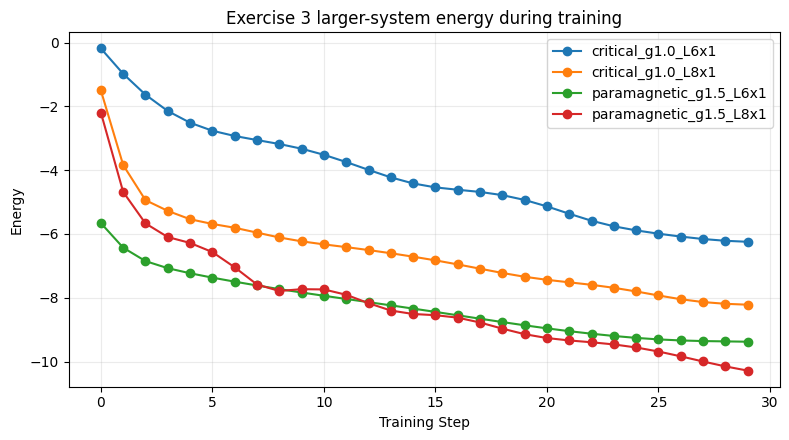

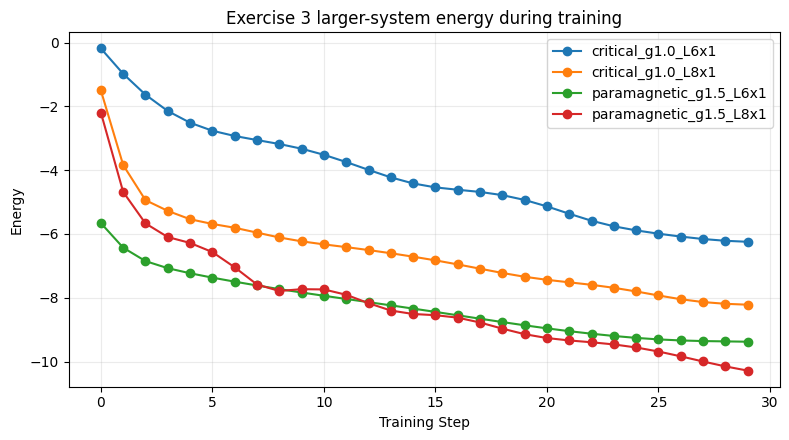

In [11]:
large_energy_history_figure = plot_training_history(
    exercise_3_large['training_history_table'],
    'energy',
    line_column='sweep_label',
    title='Exercise 3 larger-system energy during training',
)
large_energy_history_figure

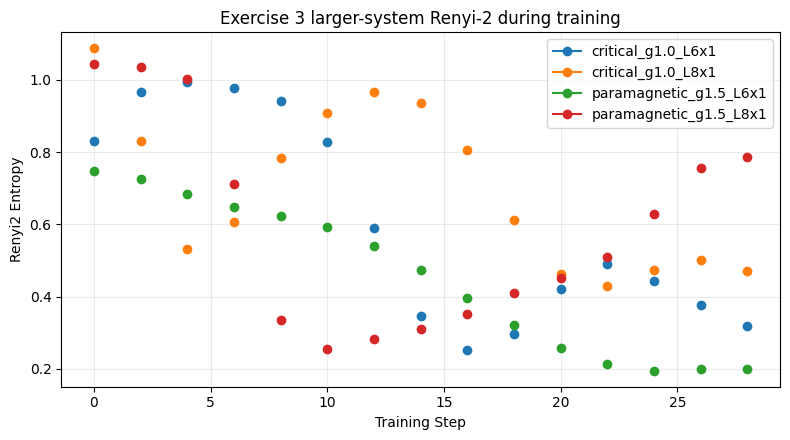

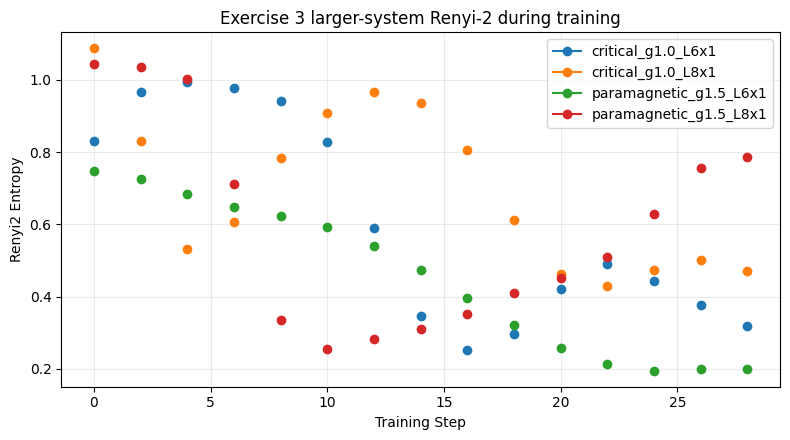

In [12]:
large_entropy_history_figure = plot_training_history(
    exercise_3_large['training_history_table'],
    'renyi2_entropy',
    line_column='sweep_label',
    title='Exercise 3 larger-system Renyi-2 during training',
)
large_entropy_history_figure

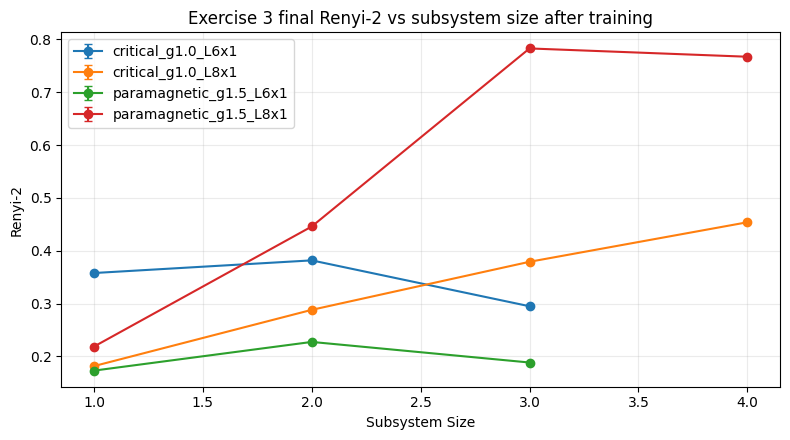

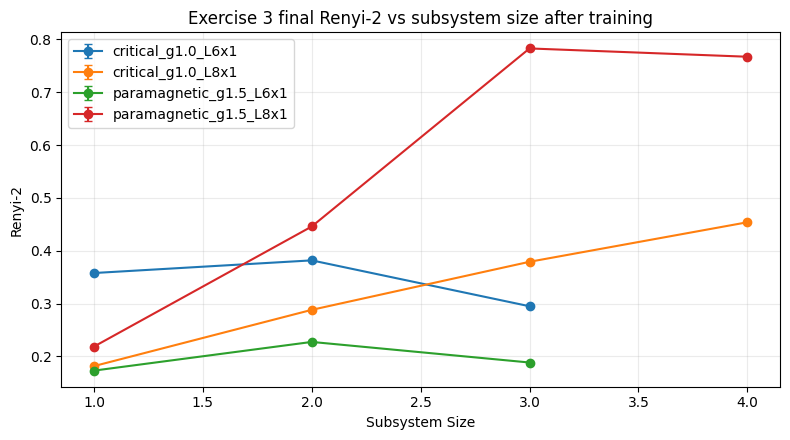

In [13]:
exercise_3_large_entropy_scan = pd.concat([
    sweep_result['entropy_scan_table'].assign(sweep_label=sweep_result['label'])
    for sweep_result in exercise_3_large['sweep_results']
], ignore_index=True)

large_entropy_scan_figure = plot_entropy_scan(
    exercise_3_large_entropy_scan.rename(columns={'renyi2': 'renyi2'}),
    line_column='sweep_label',
    title='Exercise 3 final Renyi-2 vs subsystem size after training',
)
large_entropy_scan_figure

## 3/e Optional Bonus Appendix: GHZ Training Check

The GHZ task is kept explicitly as a bonus appendix. It is a different training target from the TFIM ground-state search and is therefore separated from the required benchmark path above.


In [14]:
ghz_config = {
    'lattice_shape': (2, 2),
    'n_iter': 20,
    'n_samples': 128,
    'n_discard_per_chain': 16,
    'n_chains': 16,
    'callback_every': 2,
}

exercise_3_ghz = run_ghz_bonus_workflow(
    **selected_model,
    **ghz_config,
)

exercise_3_ghz_history = exercise_3_ghz['history_df'].copy()
exercise_3_ghz_history['model'] = 'RBM_GHZ'

pd.DataFrame([exercise_3_ghz['ghz_metrics']])

,ghz_fidelity,cat_sector_weight,half_partition_renyi2
0,0.540183,0.987677,0.004936


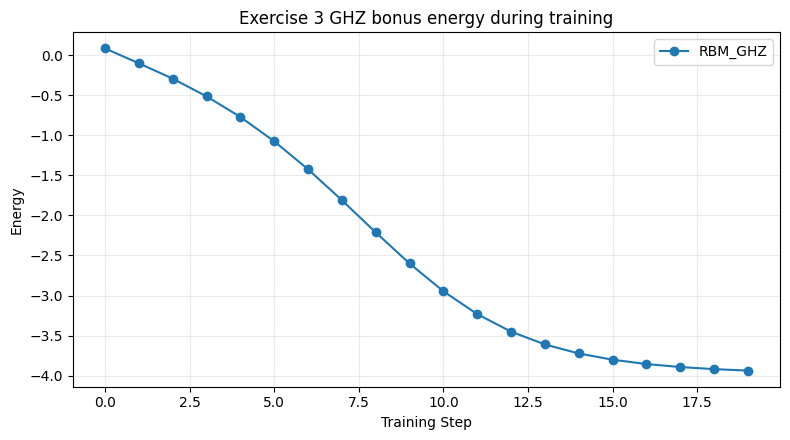

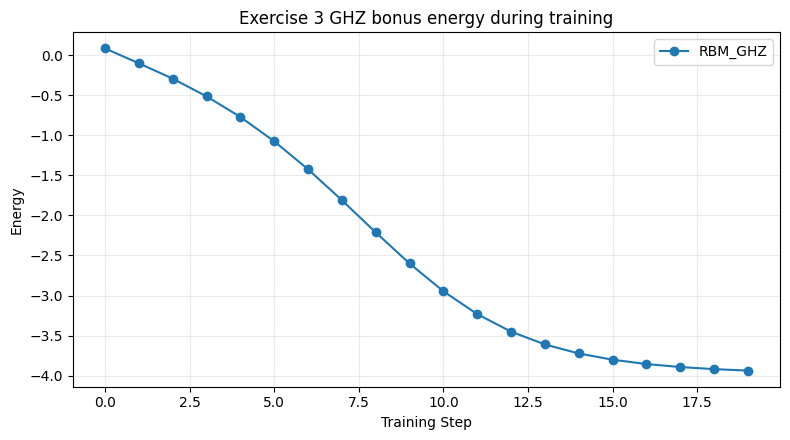

In [15]:
ghz_history_figure = plot_training_history(
    exercise_3_ghz_history,
    'energy',
    line_column='model',
    title='Exercise 3 GHZ bonus energy during training',
)
ghz_history_figure

## 3/f Optional Bonus Appendix: Entanglement-Spectrum Tail Follow-Up

The entanglement-spectrum-tail question is left as a follow-up rather than forced into this notebook. A convincing answer would require a more deliberate comparison against a truncation-based reference such as an MPS workflow or a dedicated sample-number convergence study focused on the smallest Schmidt values.


## Final Conclusions

Problem 3(a-d) is answered by the rendered training data in this notebook. The RBM choice is justified by the bounded Exercise 2 evidence, the VMC method is spelled out through the local-energy estimator plus Adam updates, and the small-system `4x1` runs show the required exact-vs-VMC benchmark directly in the energy and Renyi-2 plots. The critical point keeps both the energy relaxation and the entropy history broader than the off-critical `g = 1.5` reference, which is the expected qualitative signature of the harder, more entangled target state.

The larger-system `6x1` and `8x1` sweeps then extend the same workflow beyond the most comfortable exact benchmark. The visible trend is that training remains possible, but convergence becomes less clean and the final subsystem-size Renyi-2 curves retain stronger structure at the critical point than away from it. That is the main physical conclusion from the larger-system section: entanglement remains a useful diagnostic of where the optimization is hardest, even when exact benchmarking is no longer the central story.


## Limitations

This report keeps the Hamiltonian study on the current `(L, 1)` TFIM proxy rather than introducing a new dedicated 1D graph implementation just for the notebook. The larger-system section is therefore still modest in scale, and the GHZ plus entanglement-spectrum-tail material remains clearly labeled as bonus appendix content instead of partially supported required work. Where the sampled Renyi-2 becomes noisy or the energy no longer converges cleanly within the fixed training budget, the notebook treats that as a training limitation rather than as evidence for a sharper physical claim.


## Export Exercise 3 Artifacts

Persist the required training tables and the main benchmark figures for later report assembly.

In [16]:
small_summary_paths = save_report_table(exercise_3_small_summary, 'exercise_3_small_summary', output_dir=exercise_output_dir)
small_history_paths = save_report_table(exercise_3_small_history, 'exercise_3_small_history', output_dir=exercise_output_dir)
large_summary_paths = save_report_table(exercise_3_large['summary_table'], 'exercise_3_large_summary', output_dir=exercise_output_dir)
large_history_paths = save_report_table(exercise_3_large['training_history_table'], 'exercise_3_large_history', output_dir=exercise_output_dir)
large_entropy_scan_paths = save_report_table(exercise_3_large_entropy_scan, 'exercise_3_large_entropy_scan', output_dir=exercise_output_dir)
ghz_paths = save_report_table(pd.DataFrame([exercise_3_ghz['ghz_metrics']]), 'exercise_3_ghz_summary', output_dir=exercise_output_dir)
small_energy_path = save_report_figure(small_energy_figure, 'exercise_3_small_energy', output_dir=exercise_output_dir)
small_entropy_path = save_report_figure(small_entropy_figure, 'exercise_3_small_entropy', output_dir=exercise_output_dir)
small_benchmark_path = save_report_figure(small_benchmark_figure, 'exercise_3_small_benchmark', output_dir=exercise_output_dir)
large_energy_path = save_report_figure(large_energy_history_figure, 'exercise_3_large_energy', output_dir=exercise_output_dir)
large_entropy_path = save_report_figure(large_entropy_history_figure, 'exercise_3_large_entropy', output_dir=exercise_output_dir)
large_entropy_scan_path = save_report_figure(large_entropy_scan_figure, 'exercise_3_large_entropy_scan', output_dir=exercise_output_dir)
ghz_history_path = save_report_figure(ghz_history_figure, 'exercise_3_ghz_history', output_dir=exercise_output_dir)

build_output_manifest([
    {'section': 'exercise_3', 'name': 'small_summary', 'path': str(small_summary_paths['csv'])},
    {'section': 'exercise_3', 'name': 'small_history', 'path': str(small_history_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_summary', 'path': str(large_summary_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_history', 'path': str(large_history_paths['csv'])},
    {'section': 'exercise_3', 'name': 'large_entropy_scan', 'path': str(large_entropy_scan_paths['csv'])},
    {'section': 'exercise_3', 'name': 'ghz_summary', 'path': str(ghz_paths['csv'])},
    {'section': 'exercise_3', 'name': 'small_energy_figure', 'path': str(small_energy_path)},
    {'section': 'exercise_3', 'name': 'small_entropy_figure', 'path': str(small_entropy_path)},
    {'section': 'exercise_3', 'name': 'small_benchmark_figure', 'path': str(small_benchmark_path)},
    {'section': 'exercise_3', 'name': 'large_energy_figure', 'path': str(large_energy_path)},
    {'section': 'exercise_3', 'name': 'large_entropy_figure', 'path': str(large_entropy_path)},
    {'section': 'exercise_3', 'name': 'large_entropy_scan_figure', 'path': str(large_entropy_scan_path)},
    {'section': 'exercise_3', 'name': 'ghz_history_figure', 'path': str(ghz_history_path)},
])

,section,name,path
0,exercise_3,ghz_history_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
1,exercise_3,ghz_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
2,exercise_3,large_energy_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
3,exercise_3,large_entropy_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
4,exercise_3,large_entropy_scan,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
5,exercise_3,large_entropy_scan_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
6,exercise_3,large_history,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
7,exercise_3,large_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
8,exercise_3,small_benchmark_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
9,exercise_3,small_energy_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
